Advanced Hydroponics Crop Selector
Crops: Lettuce, Tomatoes, Spinach, Mint, Basil, Peppers, Cucumbers, Strawberries
Select crop: Mint 

=== Mint Parameters ===
pH: 5.5-6.0
EC: 1.6-2.0 mS/cm
Temperature: 15-24°C
Humidity: 70-90%
Water Flow: 1-2 L/plant/day
DO: 6-8 mg/L
CO2: 900-1300 ppm
Light: 10-14 hours/day
Systems: DWC, Kratky
Notes: High humidity lover; invasive roots.

AI Regulation Targets: pH=5.8, EC=1.6


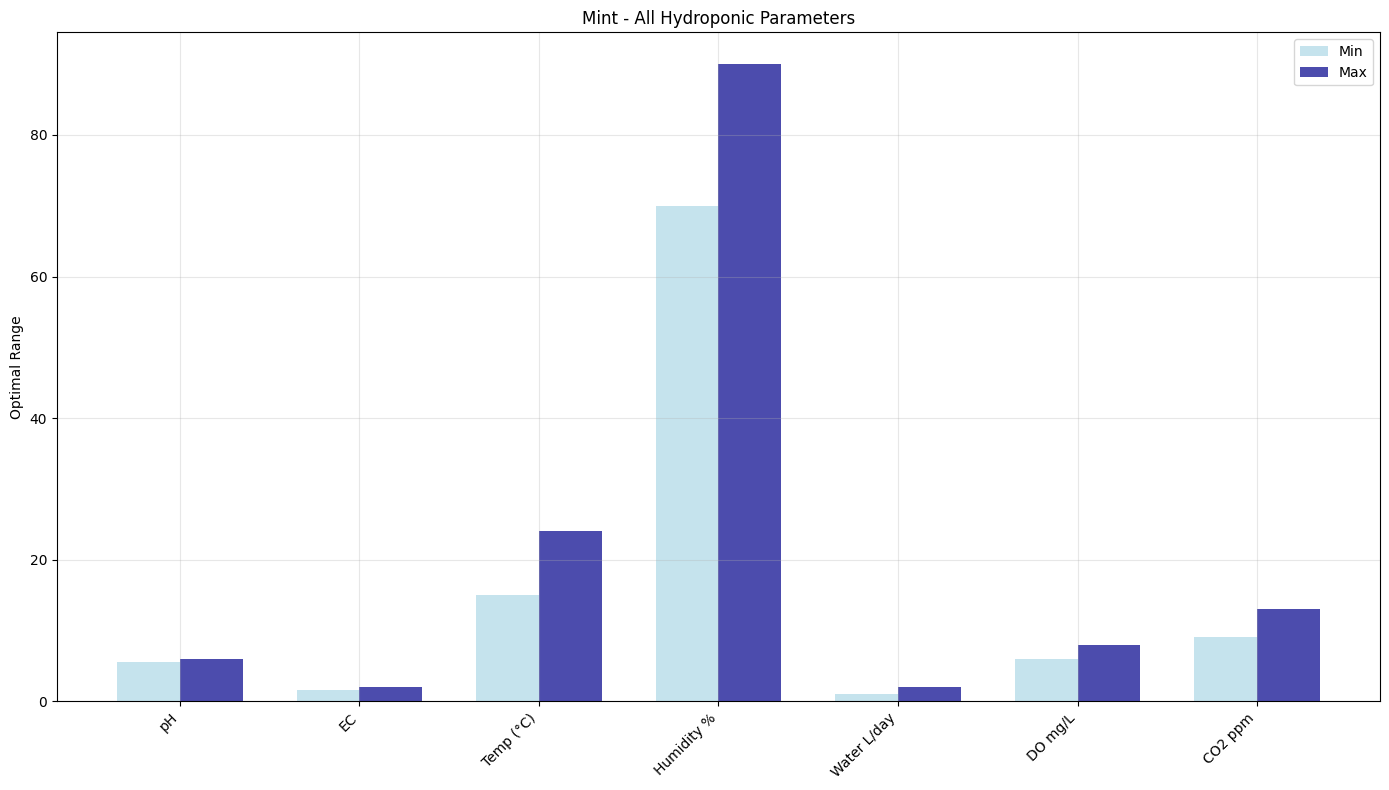

Full graph saved: mint_full_ranges.png


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import re

# Comprehensive Hydroponics Crop Database
crops_data = {
    'Lettuce': {
        'pH': '5.5-6.5',
        'EC': '1.0-1.8 mS/cm',
        'Temperature': '18-24°C',
        'Humidity': '60-80%',
        'Water Flow': '0.5-1 L/plant/day',
        'DO': '5-8 mg/L',
        'CO2': '800-1200 ppm',
        'Light': '12-16 hours/day',
        'Recommended Systems': 'NFT, DWC',
        'Notes': 'Fast growth; sensitive to high EC.'
    },
    'Tomatoes': {
        'pH': '5.5-6.5',
        'EC': '2.0-5.0 mS/cm',
        'Temperature': '20-25°C',
        'Humidity': '60-70%',
        'Water Flow': '1-3 L/plant/day',
        'DO': '6-9 mg/L',
        'CO2': '1000-1500 ppm',
        'Light': '14-18 hours/day',
        'Recommended Systems': 'Drip, Ebb & Flow',
        'Notes': 'Pollinate; watch for blossom end rot.'
    },
    'Spinach': {
        'pH': '6.0-7.0',
        'EC': '1.8-2.3 mS/cm',
        'Temperature': '15-21°C',
        'Humidity': '70-85%',
        'Water Flow': '0.5-1 L/plant/day',
        'DO': '5-7 mg/L',
        'CO2': '800-1100 ppm',
        'Light': '10-14 hours/day',
        'Recommended Systems': 'NFT, Aeroponics',
        'Notes': 'Cool temps prevent bolting.'
    },
    'Mint': {
        'pH': '5.5-6.0',
        'EC': '1.6-2.0 mS/cm',
        'Temperature': '15-24°C',
        'Humidity': '70-90%',
        'Water Flow': '1-2 L/plant/day',
        'DO': '6-8 mg/L',
        'CO2': '900-1300 ppm',
        'Light': '10-14 hours/day',
        'Recommended Systems': 'DWC, Kratky',
        'Notes': 'High humidity lover; invasive roots.'
    },
    'Basil': {
        'pH': '5.5-6.5',
        'EC': '1.0-1.6 mS/cm',
        'Temperature': '22-28°C',
        'Humidity': '60-70%',
        'Water Flow': '0.8-1.5 L/plant/day',
        'DO': '5-8 mg/L',
        'CO2': '800-1200 ppm',
        'Light': '12-16 hours/day',
        'Recommended Systems': 'NFT, DWC',
        'Notes': 'Warmth boosts aroma.'
    },
    'Peppers': {
        'pH': '5.8-6.5',
        'EC': '1.8-2.5 mS/cm',
        'Temperature': '21-27°C',
        'Humidity': '50-70%',
        'Water Flow': '1.5-2.5 L/plant/day',
        'DO': '6-9 mg/L',
        'CO2': '1000-1400 ppm',
        'Light': '14-18 hours/day',
        'Recommended Systems': 'Drip, Dutch Bucket',
        'Notes': 'Lower humidity reduces disease.'
    },
    'Cucumbers': {
        'pH': '5.5-6.0',
        'EC': '1.7-2.5 mS/cm',
        'Temperature': '21-26°C',
        'Humidity': '60-80%',
        'Water Flow': '2-4 L/plant/day',
        'DO': '6-8 mg/L',
        'CO2': '900-1300 ppm',
        'Light': '12-16 hours/day',
        'Recommended Systems': 'Drip, Ebb & Flow',
        'Notes': 'High water; trellis.'
    },
    'Strawberries': {
        'pH': '5.5-6.2',
        'EC': '1.8-2.2 mS/cm',
        'Temperature': '18-25°C',
        'Humidity': '65-80%',
        'Water Flow': '0.5-1 L/plant/day',
        'DO': '6-8 mg/L',
        'CO2': '800-1200 ppm',
        'Light': '12-14 hours/day',
        'Recommended Systems': 'NFT, Vertical Towers',
        'Notes': 'Consistent moisture key.'
    }
}

def parse_range(value):
    numbers = re.findall(r'\d+\.?\d*', value)
    if len(numbers) >= 2:
        return float(numbers[0]), float(numbers[1])
    return float(numbers[0]) if numbers else 0, 0

print("Advanced Hydroponics Crop Selector")
print("Crops:", ", ".join(crops_data.keys()))
selected_crop = input("Select crop: ").strip().title()

if selected_crop in crops_data:
    info = crops_data[selected_crop]
    print(f"\n=== {selected_crop} Parameters ===")
    for param, value in info.items():
        if param != 'Notes' and param != 'Recommended Systems':
            print(f"{param}: {value}")
    print(f"Systems: {info['Recommended Systems']}")
    print(f"Notes: {info['Notes']}")

    # Targets
    target_ph = (parse_range(info['pH'])[0] + parse_range(info['pH'])[1]) / 2
    ec_start = re.findall(r'\d+\.?\d*', info['EC'])[0]
    target_ec = float(ec_start)
    print(f"\nAI Regulation Targets: pH={target_ph:.1f}, EC={target_ec:.1f}")

    # Graph All Aspects
    params = ['pH', 'EC', 'Temp (°C)', 'Humidity %', 'Water L/day', 'DO mg/L', 'CO2 ppm']
    parse_keys = ['pH', 'EC', 'Temperature', 'Humidity', 'Water Flow', 'DO', 'CO2']
    lows, highs = [], []
    for key in parse_keys:
        low, high = parse_range(info[key])
        # Scale for viz: Humidity/%, Water L, DO mg/L, CO2 ppm/100
        if key == 'Humidity':
            low, high = low, high
        elif key == 'Water Flow':
            low, high = low, high
        elif key == 'DO':
            low, high = low, high
        elif key == 'CO2':
            low, high = low/100, high/100  # Scale down
        lows.append(low)
        highs.append(high)

    x = np.arange(len(params))
    width = 0.35
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.bar(x - width/2, lows, width, label='Min', alpha=0.7, color='lightblue')
    ax.bar(x + width/2, highs, width, label='Max', alpha=0.7, color='darkblue')
    ax.set_ylabel('Optimal Range')
    ax.set_title(f'{selected_crop} - All Hydroponic Parameters')
    ax.set_xticks(x)
    ax.set_xticklabels(params, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{selected_crop.lower()}_full_ranges.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Full graph saved: {selected_crop.lower()}_full_ranges.png")
else:
    print("Invalid crop.")